# **1. 환경 설정 및 데이터 다운로드**

- 구글 드라이브 연결(데이터셋 불러오기)
- Visual-Clutter 라이브러리 설치
- Visual-Clutter 오류 발생 시 확인 로직
- 분석할 이미지 다운로드해 Colab 상에 복사

In [1]:
import os
import sys
import shutil
from google.colab import drive
import cv2
import numpy as np

# ==========================================
# 1. 구글 드라이브 연결 및 데이터셋 설정
# ==========================================
print("📂 구글 드라이브를 연결합니다...")
drive.mount('/content/drive')

# 내 드라이브 > dataset_lld > simple_text_logo 폴더
DRIVE_DIR = '/content/drive/MyDrive/dataset_lld/simple_text_logo'

if not os.path.exists(DRIVE_DIR):
    os.makedirs(DRIVE_DIR)
    print(f"✅ 폴더 생성 완료: {DRIVE_DIR}")
else:
    print(f"✅ 이미 폴더가 존재합니다: {DRIVE_DIR}")

# ==========================================
# 2. Visual-Clutter 라이브러리 설정
# ==========================================
# 기존 폴더 정리
if os.path.exists('visual-clutter'):
    shutil.rmtree('visual-clutter')

try:
    import pyrtools
    print("   ✅ pyrtools 이미 설치됨")
except ImportError:
    print("   ⬇️ pyrtools 설치 중...")
    !pip install pyrtools

# 라이브러리 다운로드
!git clone https://github.com/kargaranamir/visual-clutter.git

# 경로 추가
if '/content/visual-clutter' not in sys.path:
    sys.path.append('/content/visual-clutter')

print("✅ Visual-Clutter 라이브러리 소스 다운로드 완료")

# ==========================================
# * Visual-Clutter 다운로드오류 발생 시
# ==========================================
# 1. 기존 폴더가 있다면 강제로 삭제
target_dir = '/content/visual-clutter'
if os.path.exists(target_dir):
    print(f"기존 폴더 삭제: {target_dir}")
    shutil.rmtree(target_dir)

# 2. 라이브러리 다시 다운로드 (Git Clone)
print("라이브러리 새로 다운로드")
result = os.system(f"git clone https://github.com/kargaranamir/visual-clutter.git {target_dir}")

if result != 0:
    print("❌다운로드 실패")
else:
    print("✅다운로드 완료")

# 3. 폴더 구조 확인
if os.path.exists(target_dir):
    # 내부 파일 목록 출력
    for root, dirs, files in os.walk(target_dir):
        level = root.replace(target_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            if f.endswith('.py'): # 파이썬 파일만 표시
                print(f"{subindent}{f}")
else:
    print("❌폴더가 생성되지 않았습니다.")

# 4. 시스템 경로에 추가 및 테스트
print("\n   🔗 시스템 경로 연결 및 임포트 테스트...")
if target_dir not in sys.path:
    sys.path.append(target_dir)

try:
    # 여기서 실제로 import가 되는지 테스트
    from visual_clutter.clutter import Vlc
    print("\n   🎉 [성공] 'Vlc' 클래스를 정상적으로 불러왔습니다!")
except ImportError as e:
    print(f"\n   ❌ [실패] 여전히 불러올 수 없습니다. 에러 내용: {e}")
    print("   💡런타임 > 런타임 연결 해제 및 삭제 후 다시 시도")

📂 구글 드라이브를 연결합니다...
Mounted at /content/drive
✅ 이미 폴더가 존재합니다: /content/drive/MyDrive/dataset_lld/simple_text_logo
   ⬇️ pyrtools 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.5/116.5 kB 3.9 MB/s eta 0:00:00
Cloning into 'visual-clutter'...
remote: Enumerating objects: 1428, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 1428 (delta 28), reused 5 (delta 4), pack-reused 1380 (from 1)
Receiving objects: 100% (1428/1428), 13.46 MiB | 13.27 MiB/s, done.
Resolving deltas: 100% (345/345), done.
✅ Visual-Clutter 라이브러리 소스 다운로드 완료
기존 폴더 삭제: /content/visual-clutter
라이브러리 새로 다운로드
✅다운로드 완료
visual-clutter/
    setup.py
    tests/
        test_clutter.py
        test_utils.py
    .github/
        workflows/
    visual_clutter/
        clutter.py
        utils.py
        __init__.py
    .git/
        branches/
        refs/
            heads/
            tags/
            remotes/
                origin/
        objects/
   

In [2]:
from google.colab import drive
import os
import shutil
import glob

# 1. 구글 드라이브 연결
drive.mount('/content/drive')

# 2. 경로 설정
DRIVE_DIR = '/content/drive/MyDrive/dataset_lld/simple_text_logo' # 이미지가 저장된 드라이브 폴더
WORK_DIR = '/content/lld_dataset' # 분석 작업용 코랩 폴더

# 3. 폴더 복사 (드라이브 -> 코랩)
# 드라이브에서 직접 분석하면 속도가 느릴 수 있어 복사
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR) # 기존 폴더 청소

# 폴더 통째로 복사
try:
    shutil.copytree(DRIVE_DIR, WORK_DIR)

    # 파일 개수 확인
    num_files = len(glob.glob(os.path.join(WORK_DIR, '*')))
    print(f"✅ 복사 완료! 총 {num_files}개의 이미지")

except FileNotFoundError:
    print("구글 드라이브에 'simple_text_logo' 폴더가 없음.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 복사 완료! 총 12개의 이미지


# **2.엔트로피 측정 알고리즘**

- Benchmark: Feature Congestion(Visual Clutter)
- Proposed: Custom Entropy Algorithm(Texture + Color)
- 결과 분석
  - 스피어만 상관게수 분석: '누가 더 복잡한가?'의 순위 일치 여부
  - 켄달 타우: 두 이미지를 골랐을 때 대소 관계가 일치할 확률
  - Top-K 일치율 분석
  - 순위 산점도: 두 알고리즘이 유사한 판단을 내리고 있는지 확인
  


✅ 11개의 이미지를 분석합니다...

Image Name      | Tex(H)   | Col(H)   | My Algo  | Feature Congestion
---------------------------------------------------------------------------
gmarket.png     | 1.805    | 1.667    | 1.736    | 11.9472
philips.png     | 0.453    | 0.401    | 0.427    | 3.2980
namuwiki.png    | 1.193    | 1.050    | 1.122    | 4.1377
ebs1tv.png      | 1.588    | 1.420    | 1.504    | 8.3570
redbull.png     | 1.879    | 1.507    | 1.693    | 10.4635
chanel.png      | 0.767    | 0.781    | 0.774    | 5.5511
google.png      | 2.032    | 1.555    | 1.794    | 8.7572
netflix.jpg     | 0.680    | 0.483    | 0.581    | 1.3750
subway.jpg      | 2.976    | 1.390    | 2.183    | 5.8649
sony.png        | 0.689    | 0.746    | 0.718    | 5.8446
naver.png       | 1.501    | 1.369    | 1.435    | 6.5771


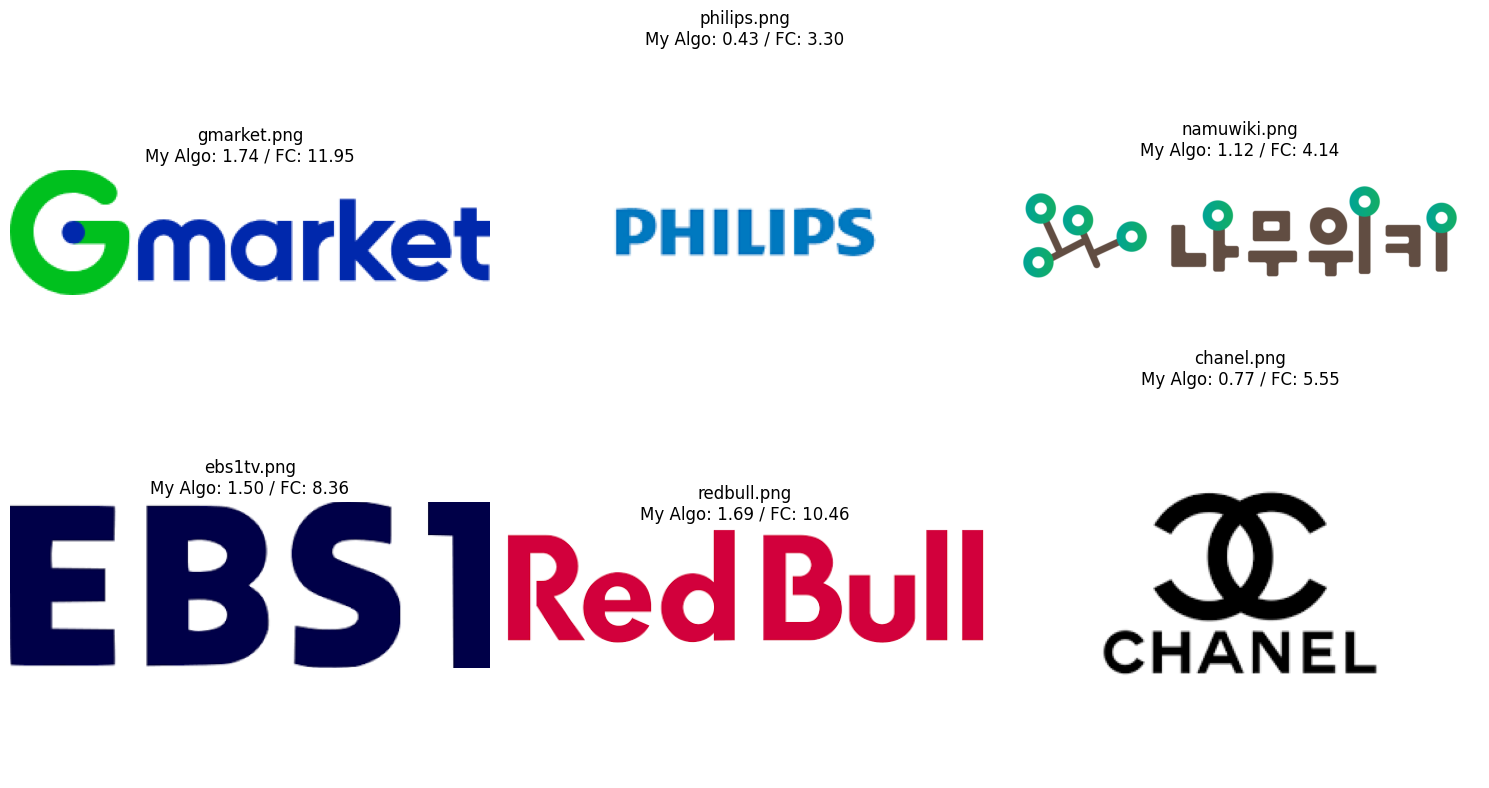

In [3]:
import os
import sys
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import entropy
from PIL import Image

# ==========================================
# 라이브러리 경로 확인
# ==========================================
# 다운로드 받은 폴더를 파이썬 경로에 추가
if '/content/visual-clutter' not in sys.path:
    sys.path.append('/content/visual-clutter')

# ==========================================
# 1. Feature Congestion
# ==========================================
def preprocess_and_calculate_fc(original_image_path):
    try:
        from visual_clutter.clutter import Vlc

        # 1. 이미지 로드
        img = Image.open(original_image_path)

        # 2. 전처리: 투명 배경(Alpha)이 있는 경우 흰색 배경으로 병합
        # (Feature Congestion 알고리즘은 투명도를 처리하지 못해 0점이 나오는 문제를 방지하기 위함)
        if img.mode in ('RGBA', 'LA') or (img.mode == 'P' and 'transparency' in img.info):
            background = Image.new("RGB", img.size, (255, 255, 255))
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            background.paste(img, mask=img.split()[3])
            clean_img = background
        else:
            clean_img = img.convert("RGB")

        # 3. 임시 파일 저장 (라이브러리가 파일 경로를 입력받기 때문)
        temp_path = "temp_for_fc.jpg"
        clean_img.save(temp_path, "JPEG", quality=95)

        # 4. 계산 실행
        # [수정 2] 클래스 생성자도 Vlc로 변경
        clt = Vlc(temp_path)
        score, _ = clt.getClutter_FC()

        return score

    except ImportError as e:
        print(f"❌ Import 실패: {e}")
        return 0.0
    except Exception as e:
        # 상세한 에러 메시지 출력
        print(f"⚠️ FC Error ({os.path.basename(original_image_path)}): {e}")
        return 0.0

# ==========================================
# 2. Custom Entropy (Texture + Color)
# ==========================================
def calculate_texture_entropy(image_np):
    # Grayscale 변환
    if len(image_np.shape) == 3:
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_np

    # 히스토그램 엔트로피 계산
    hist, _ = np.histogram(gray.flatten(), bins=256, range=[0, 256])
    prob_dist = hist / (hist.sum() + 1e-10) # 0 나누기 방지
    return entropy(prob_dist, base=2)

def calculate_color_entropy(image_np, k=5):
    # K-Means를 이용한 색상 분포 엔트로피
    # 속도를 위해 이미지 크기 축소 (150x150)
    resized = cv2.resize(image_np, (150, 150))
    pixels = resized.reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)

    counts = np.bincount(kmeans.labels_, minlength=k)
    prob_dist = counts / (counts.sum() + 1e-10)
    return entropy(prob_dist, base=2)

def calculate_hybrid_entropy(image_np, alpha=0.5, beta=0.5):
    # 제안 알고리즘: Texture와 Color 엔트로피의 선형 결합
    tex = calculate_texture_entropy(image_np)
    col = calculate_color_entropy(image_np, k=8)
    return (alpha * tex) + (beta * col), tex, col

# ==========================================
# 3. Main 실행
# ==========================================
if __name__ == "__main__":
    BASE_DIR = '/content/lld_dataset'

    image_paths = glob.glob(os.path.join(BASE_DIR, '*'))

    # 이미지 파일만 필터링
    valid_extensions = ('.png', '.jpg', '.jpeg', '.svg')
    image_paths = [p for p in image_paths if p.lower().endswith(valid_extensions)]

    if not image_paths:
        print(f"❌ '{BASE_DIR}' 경로에 이미지가 없습니다. Step 1(다운로드)을 먼저 실행해주세요.")
    else:
        print(f"\n✅ {len(image_paths)}개의 이미지를 분석합니다...\n")
        print(f"{'Image Name':<15} | {'Tex(H)':<8} | {'Col(H)':<8} | {'My Algo':<8} | {'Feature Congestion':<18}")
        print("-" * 75)

        results = []

        for path in image_paths:
            name = os.path.basename(path)
            try:
                # 1. Feature Congestion (Vlc 사용)
                fc_score = preprocess_and_calculate_fc(path)

                # 2. Custom Algorithm (제안 알고리즘)
                img_pil = Image.open(path).convert('RGB')
                img_np = np.array(img_pil)
                hybrid, tex, col = calculate_hybrid_entropy(img_np)

                results.append({'img': img_np, 'name': name, 'hybrid': hybrid, 'fc': fc_score})

                print(f"{name[:15]:<15} | {tex:.3f}    | {col:.3f}    | {hybrid:.3f}    | {fc_score:.4f}")

            except Exception as e:
                print(f"Error processing {name}: {e}")

        # 결과 시각화
        if results:
            plt.figure(figsize=(15, 8))
            for i, res in enumerate(results[:6]): # 최대 6개까지만 표시
                plt.subplot(2, 3, i+1)
                plt.imshow(res['img'])
                plt.title(f"{res['name']}\nMy Algo: {res['hybrid']:.2f} / FC: {res['fc']:.2f}")
                plt.axis('off')
            plt.tight_layout()
            plt.show()


📊 [순위 기반 분석 결과]
1. 스피어만 상관계수 (Rank Correlation) : 0.7909 (p-value: 0.0037)
2. 켄달 타우 (Concordance Rate)       : 0.6000 (p-value: 0.0099)
------------------------------------------------------------

🏆 [Top-5 복잡도 이미지 비교]
   -> FC가 뽑은 Top-5: ['gmarket.png', 'naver.png', 'redbull.png', 'ebs1tv.png', 'google.png']
   -> 내가 뽑은 Top-5: ['subway.jpg', 'gmarket.png', 'redbull.png', 'ebs1tv.png', 'google.png']
   -> 일치하는 이미지 (4개): ['google.png', 'ebs1tv.png', 'gmarket.png', 'redbull.png']
   🔥 Top-5 일치율: 80.0%


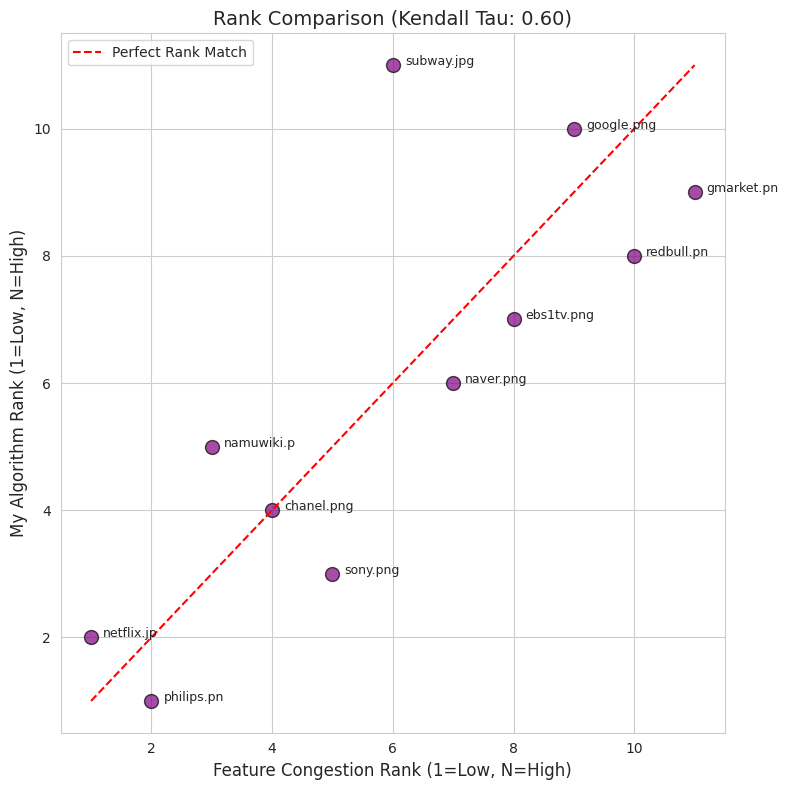

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_ranking_performance(results_data, top_k=5):
    """
    순위(Ranking) 관점에서 두 알고리즘을 비교하는 분석 함수
    """
    if not results_data or len(results_data) < 2:
        print("❌ 데이터가 부족합니다.")
        return

    # 1. 데이터 추출
    names = [item['name'] for item in results_data]
    fc_scores = np.array([item['fc'] for item in results_data])
    my_scores = np.array([item['hybrid'] for item in results_data])

    # 2. 순위 기반 상관계수 계산
    # (1) 스피어만 (전체적인 순위 경향성)
    spearman_corr, spearman_p = stats.spearmanr(fc_scores, my_scores)

    # (2) 켄달 타우 (두 이미지를 골랐을 때 대소 관계가 일치할 확률)!
    kendall_corr, kendall_p = stats.kendalltau(fc_scores, my_scores)

    print("\n📊 [순위 기반 분석 결과]")
    print("=" * 60)
    print(f"1. 스피어만 상관계수 (Rank Correlation) : {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
    print(f"2. 켄달 타우 (Concordance Rate)       : {kendall_corr:.4f} (p-value: {kendall_p:.4f})")
    print("-" * 60)

    # 3. Top-K 일치율 분석 (실무적으로 가장 중요)
    # 점수가 높은 순서대로 인덱스 정렬
    fc_top_indices = np.argsort(fc_scores)[::-1][:top_k]
    my_top_indices = np.argsort(my_scores)[::-1][:top_k]

    fc_top_names = set([names[i] for i in fc_top_indices])
    my_top_names = set([names[i] for i in my_top_indices])

    intersection = fc_top_names.intersection(my_top_names)
    overlap_score = len(intersection) / top_k * 100

    print(f"\n🏆 [Top-{top_k} 복잡도 이미지 비교]")
    print(f"   -> FC가 뽑은 Top-{top_k}: {list(fc_top_names)}")
    print(f"   -> 내가 뽑은 Top-{top_k}: {list(my_top_names)}")
    print(f"   -> 일치하는 이미지 ({len(intersection)}개): {list(intersection)}")
    print(f"   🔥 Top-{top_k} 일치율: {overlap_score:.1f}%")
    print("=" * 60)

    # 4. 순위 산점도 (Rank-Rank Plot)
    # 점수 자체가 아니라 '등수'를 비교합니다.
    fc_ranks = stats.rankdata(fc_scores)
    my_ranks = stats.rankdata(my_scores)

    plt.figure(figsize=(8, 8))
    sns.set_style("whitegrid")

    plt.scatter(fc_ranks, my_ranks, s=100, color='purple', alpha=0.7, edgecolors='k')

    # 텍스트 태깅
    for i, name in enumerate(names):
        plt.text(fc_ranks[i]+0.2, my_ranks[i], name[:10], fontsize=9)

    # y=x (순위가 완벽히 일치하면 이 선 위에 점이 찍힘)
    max_rank = len(names)
    plt.plot([1, max_rank], [1, max_rank], 'r--', label='Perfect Rank Match')

    plt.title(f'Rank Comparison (Kendall Tau: {kendall_corr:.2f})', fontsize=14)
    plt.xlabel('Feature Congestion Rank (1=Low, N=High)', fontsize=12)
    plt.ylabel('My Algorithm Rank (1=Low, N=High)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행
if __name__ == "__main__":
    if 'results' in locals() and results:
        analyze_ranking_performance(results, top_k=5)

# **3.정렬 순서 효과 검증**

- 저엔트로피 → 고엔트로피 순서 vs 고엔트로피 → 저엔트로피 순서 중 무엇이 더 효율적인지 검증
- CLIP Score를 바탕으로 통합 효율 효과 비교

In [5]:
!pip install openai requests

In [7]:
import os
import json
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from openai import OpenAI
import requests
from io import BytesIO
import random

# =================================================================
# [Class 1] VisualConcept: 이미지+텍스트+점수 관리
# =================================================================
class VisualConcept:
    def __init__(self, image_path, description):
        self.path = image_path
        self.name = os.path.basename(image_path)
        self.description = description
        self.image_pil = Image.open(image_path).convert("RGB")
        self.image_np = np.array(self.image_pil)

        # 지표
        self.entropy_score = 0.0
        self.clip_score = 0.0

    def analyze_complexity(self):
        score, _, _ = calculate_hybrid_entropy(self.image_np)
        self.entropy_score = score

# =================================================================
# [Class 2] CLIP Score 평가기
# =================================================================
class CLIPEvaluator:
    def __init__(self):
        print("⏳ Loading CLIP model for evaluation...")
        # OpenAI의 공식 CLIP 모델 사용
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self.device)

    def calculate_score(self, image_pil, text_description):
        """
        생성된 이미지와 의도한 텍스트 설명 사이의 유사도 측정
        """
        inputs = self.processor(
            text=[text_description],
            images=image_pil,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77,
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # Logits per image: 높을수록 이미지와 텍스트가 잘 매칭됨
        score = outputs.logits_per_image.item()
        return score

# =================================================================
# [Class 3] AI 생성기 (순서 실험용 프롬프트 설계)
# =================================================================
class CreativeMerger:
    def __init__(self, api_key):
        self.client = OpenAI(api_key=api_key)

        self.base_instruction = """
        You are an expert logo designer.
        Your task is to merge two visual concepts into one cohesive, high-quality logo or symbol.
        Do NOT simply place two images side-by-side. Blend them conceptually.
        Do NOT add any text, words, or letters unless explicitly described in the concepts.
        """

    def generate_merged_result(self, base_concept, modifier_concept, order_label, seed_val):
        combined_prompt = f"""
        {self.base_instruction}

        [Visual Structure Requirement]
        1. Primary Base Structure (Main shape): {base_concept.description}
        2. Secondary Style/Modifier (Texture/Color): {modifier_concept.description}

        [Goal]
        Apply the visual features of the 'Secondary Modifier' onto the form of the 'Primary Base Structure'.
        Create a single, clean, vector-style logo on a white background.
        """

        print(f"   🤖 [DALL-E 3] Generating ({order_label}): Base='{base_concept.name}' + Mod='{modifier_concept.name}' | Seed: {seed_val}...")

        try:
            response = self.client.images.generate(
                model="dall-e-3",
                prompt=combined_prompt,
                size="1024x1024",
                quality="standard",
                n=1,
                style="vivid" # 스타일 고정
            )

            image_url = response.data[0].url
            generated_description = response.data[0].revised_prompt

            res = requests.get(image_url)
            res.raise_for_status()
            generated_image = Image.open(BytesIO(res.content)).convert("RGB")

            return generated_image, generated_description

        except Exception as e:
            print(f"Error: {e}")
            return base_concept.image_pil.copy(), "Error generating description"

📊 모든 이미지의 엔트로피를 계산하고 정렬

🎲 이미지 2장을 무작위로 선택합니다...
   🔹 선택 1 (상대적 Low): chanel.png (Score: 0.77)
   🔸 선택 2 (상대적 High): subway.jpg (Score: 2.18)
⏳ Loading CLIP model for evaluation...

🔬 실험 시작: 각 케이스별 3회 반복 측정

--- [Trial 1/3] (Seed: 42) ---
   🤖 [DALL-E 3] Generating (Low->High): Base='chanel.png' + Mod='subway.jpg' | Seed: 42...
   🤖 [DALL-E 3] Generating (High->Low): Base='subway.jpg' + Mod='chanel.png' | Seed: 42...

--- [Trial 2/3] (Seed: 100) ---
   🤖 [DALL-E 3] Generating (Low->High): Base='chanel.png' + Mod='subway.jpg' | Seed: 100...
   🤖 [DALL-E 3] Generating (High->Low): Base='subway.jpg' + Mod='chanel.png' | Seed: 100...

--- [Trial 3/3] (Seed: 2024) ---
   🤖 [DALL-E 3] Generating (Low->High): Base='chanel.png' + Mod='subway.jpg' | Seed: 2024...
   🤖 [DALL-E 3] Generating (High->Low): Base='subway.jpg' + Mod='chanel.png' | Seed: 2024...

📊 최종 실험 통계 리포트
🟥 [Case A: Low -> High] 평균: 30.94 (표준편차: ±2.84)
🟦 [Case B: High -> Low] 평균: 26.31 (표준편차: ±1.18)

✅ 결론: '단순(Low) 이미지'를 Base로 두는

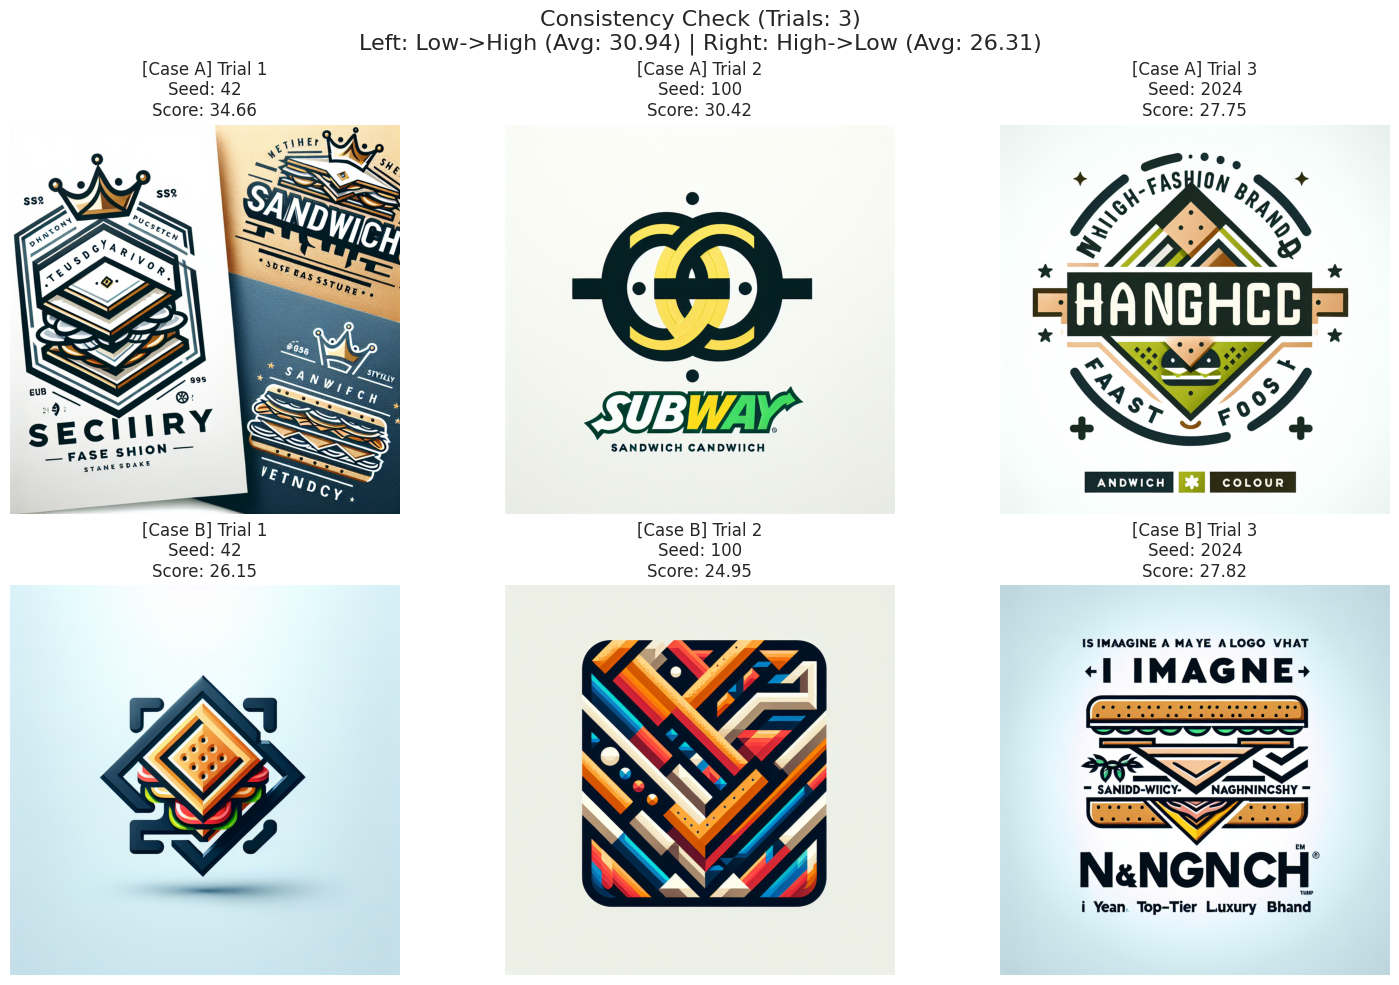

In [26]:
# =================================================================
# Main Execution
# =================================================================
if __name__ == "__main__":
    OPENAI_API_KEY = "x"

    if OPENAI_API_KEY == "x":
        print("❌ 오류: OPENAI_API_KEY를 설정해주세요!")
    else:
        BASE_DIR = '/content/lld_dataset'
        METADATA_PATH = os.path.join(BASE_DIR, 'metadata.json')

        # 1. 데이터 로드 및 객체 생성
        image_paths = glob.glob(os.path.join(BASE_DIR, '*'))
        valid_exts = ('.png', '.jpg', '.jpeg')
        image_paths = [p for p in image_paths if p.lower().endswith(valid_exts)]

       # 메타데이터 로드 (한글 설명)
        if os.path.exists(METADATA_PATH):
          with open(METADATA_PATH, 'r', encoding='utf-8') as f:
              metadata = json.load(f)
        else:
            print("❌ 메타데이터 파일이 없습니다.")
            metadata = {}

        concepts = []
        for path in image_paths:
            fname = os.path.basename(path)
            desc = metadata.get(fname, "A generic logo")
            concepts.append(VisualConcept(path, desc))

        # 2. 엔트로피 계산 및 정렬
        print("📊 모든 이미지의 엔트로피를 계산하고 정렬")
        for c in concepts:
            c.analyze_complexity()

        # 점수 기준 오름차순 정렬 (Low -> High)
        concepts.sort(key=lambda x: x.entropy_score)

        if len(concepts) < 2:
             print("❌ 비교할 이미지가 부족합니다.")
        else:
           print("\n🎲 이미지 2장을 무작위로 선택합니다...")
           selected_pair = random.sample(concepts, 2)
           c1, c2 = selected_pair[0], selected_pair[1]

           # 둘 중 엔트로피가 낮은 것을 low_c, 높은 것을 high_c로 지정
           if c1.entropy_score < c2.entropy_score:
               low_c, high_c = c1, c2
           else:
               low_c, high_c = c2, c1

           print(f"   🔹 선택 1 (상대적 Low): {low_c.name} (Score: {low_c.entropy_score:.2f})")
           print(f"   🔸 선택 2 (상대적 High): {high_c.name} (Score: {high_c.entropy_score:.2f})")
           print("="*80)

           # 도구 초기화
           merger = CreativeMerger(api_key=OPENAI_API_KEY)
           evaluator = CLIPEvaluator()

           # =========================================================
           # [핵심 변경] N회 반복 실험 (N=3)
           # =========================================================
           NUM_TRIALS = 3  # 반복 횟수 (비용 고려하여 조정하세요)
           SEEDS = [42, 100, 2024] # 고정된 시드 값 리스트 (재현성용)

           results_A = {"scores": [], "images": [], "texts": []}
           results_B = {"scores": [], "images": [], "texts": []}

           print(f"\n🔬 실험 시작: 각 케이스별 {NUM_TRIALS}회 반복 측정")

           for i in range(NUM_TRIALS):
               current_seed = SEEDS[i]
               print(f"\n--- [Trial {i+1}/{NUM_TRIALS}] (Seed: {current_seed}) ---")

               # [Case A] Low -> High
               img_A, text_A = merger.generate_merged_result(low_c, high_c, "Low->High", current_seed)
               score_A = evaluator.calculate_score(img_A, text_A)
               results_A["scores"].append(score_A)
               results_A["images"].append(img_A)
               results_A["texts"].append(text_A)

               # [Case B] High -> Low
               img_B, text_B = merger.generate_merged_result(high_c, low_c, "High->Low", current_seed)
               score_B = evaluator.calculate_score(img_B, text_B)
               results_B["scores"].append(score_B)
               results_B["images"].append(img_B)
               results_B["texts"].append(text_B)

           # =========================================================
           # 결과 통계 분석
           # =========================================================
           avg_A = np.mean(results_A["scores"])
           std_A = np.std(results_A["scores"])

           avg_B = np.mean(results_B["scores"])
           std_B = np.std(results_B["scores"])

           print("\n" + "="*80)
           print("📊 최종 실험 통계 리포트")
           print("="*80)
           print(f"🟥 [Case A: Low -> High] 평균: {avg_A:.2f} (표준편차: ±{std_A:.2f})")
           print(f"🟦 [Case B: High -> Low] 평균: {avg_B:.2f} (표준편차: ±{std_B:.2f})")

           if avg_A > avg_B:
               print("\n✅ 결론: '단순(Low) 이미지'를 Base로 두는 것이 통계적으로 더 우수합니다.")
           else:
               print("\n✅ 결론: '복잡(High) 이미지'를 Base로 두는 것이 통계적으로 더 우수합니다.")
           print("="*80)

           # =========================================================
           # 결과 시각화
           # =========================================================
           plt.figure(figsize=(5 * NUM_TRIALS, 10))

           plt.suptitle(f"Consistency Check (Trials: {NUM_TRIALS})\nLeft: Low->High (Avg: {avg_A:.2f}) | Right: High->Low (Avg: {avg_B:.2f})", fontsize=16)

           for i in range(NUM_TRIALS):
                # -----------------------------------------------------
                # [첫 번째 줄] Case A: Low -> High
                # -----------------------------------------------------
                # subplot 인덱스는 1부터 시작합니다.
                # (2행, N열 그리드에서 i+1 번째 위치)
                plt.subplot(2, NUM_TRIALS, i + 1)
                plt.imshow(results_A["images"][i])
                plt.title(f"[Case A] Trial {i+1}\nSeed: {SEEDS[i]}\nScore: {results_A['scores'][i]:.2f}", fontsize=12)
                plt.axis('off')

                # -----------------------------------------------------
                # [두 번째 줄] Case B: High -> Low
                # -----------------------------------------------------
                # (2행, N열 그리드에서 N + i + 1 번째 위치 -> 두 번째 줄로 넘어감)
                plt.subplot(2, NUM_TRIALS, NUM_TRIALS + i + 1)
                plt.imshow(results_B["images"][i])
                plt.title(f"[Case B] Trial {i+1}\nSeed: {SEEDS[i]}\nScore: {results_B['scores'][i]:.2f}", fontsize=12)
                plt.axis('off')

           plt.tight_layout()
           plt.show()
